# Physics-Guided Conditional DDPM for MRMS Rainfall Nowcasting

This notebook contains a clean, GitHub-ready implementation of a conditional diffusion model for MRMS rainfall nowcasting. The workflow is separated into readable cells so the training code, diffusion model, physics terms, sampling routine, and validation plots can be reviewed independently.

The model uses the first 60 MRMS frames as conditioning input and predicts the next 30 rainfall frames. A DDPM-style reverse denoising process is trained to generate future rainfall sequences, while physics-inspired regularization encourages smoother temporal evolution, mass consistency, and physically plausible storm displacement.

> **Before running:** Download this jupyter notebook file and put it in your MSI. All the directories are the directories of the MSI, so we will be able to run the code without even changing the directories. You can change the save directories, if problem occurs during saving.


## Physics-guided component

The physics part is designed to make the generated rainfall sequence behave more like an evolving storm field instead of independent image patches. It does **not** replace the neural network; it regularizes or selects diffusion samples using physically motivated constraints.

### 1. Advection-diffusion idea

Rainfall intensity is treated as a scalar field moving with an estimated horizontal velocity field. A simplified advection-diffusion form is:

$$
\frac{\partial R}{\partial t} + u\frac{\partial R}{\partial x} + v\frac{\partial R}{\partial y} = \kappa \nabla^2 R,
$$

where $R$ is rainfall rate, $u$ and $v$ describe storm motion, and $\kappa$ controls spatial diffusion/smoothing. In the notebook, this idea is used to create an advected baseline and to score whether a generated sequence evolves consistently with recent storm motion.

### 2. Mass or rain-volume consistency

For short nowcasting windows, the total rain amount should not change unrealistically from one frame to the next unless the observations support growth or decay. The physics score penalizes samples that create too much spurious light rain or lose the main storm mass too quickly.

### 3. Temporal shape-change constraint

The generated storm should move and deform over time, not remain frozen. The temporal loss encourages changes between consecutive predicted frames while discouraging noisy pixel-level flickering.

### 4. Ensemble-based physics selection

Because diffusion sampling can produce multiple realizations, the independent validation section generates several candidate future sequences and selects the realization with the best physics score. This keeps the probabilistic benefit of DDPM while choosing the sample that best satisfies storm-evolution constraints.


# Part A — Training the conditional DDPM nowcasting model

This part trains the model and saves the best checkpoint plus validation plots.

## Part A: Initial Setup

Code section separated for readability and easier GitHub review.

In [1]:
import os
import glob
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

## Part A: Settings

Define paths, training hyperparameters, diffusion settings, rainfall normalization constants, and visualization options.

In [2]:
DATA_DIR = "/scratch.global/1subed042/mrms_3hr_cubes_128"

SAVE_DIR = "/scratch.global/1subed042/diffusion_nowcast_final_temporal_shape_all_val"
os.makedirs(SAVE_DIR, exist_ok=True)

VAL_FIG_DIR = os.path.join(SAVE_DIR, "all_validation_two_row_plots")
os.makedirs(VAL_FIG_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, "best_diffusion_nowcast_temporal_shape.pth")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

INPUT_STEPS = 60
OUTPUT_STEPS = 30
TOTAL_STEPS = INPUT_STEPS + OUTPUT_STEPS

BATCH_SIZE = 4
NUM_EPOCHS = 10
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-5
NUM_WORKERS = 4

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15

DIFFUSION_STEPS = 50
BETA_START = 1e-4
BETA_END = 0.02

BASE_CHANNELS = 64
TIME_EMB_DIM = 256
COND_EMB_CHANNELS = 32

RAIN_NORM = 20.0
RAIN_THRESHOLD = 0.2
RAIN_THRESHOLD_NORM = RAIN_THRESHOLD / RAIN_NORM

POST_RAIN_THRESHOLD_MMHR = 0.35
POST_RAIN_THRESHOLD_NORM = POST_RAIN_THRESHOLD_MMHR / RAIN_NORM

LOSS_CROP = 8
USE_AMP = True

# Stronger temporal/shape-changing settings
LAMBDA_NOISE = 1.0
LAMBDA_RECON = 0.7
LAMBDA_HEAVY = 0.03
LAMBDA_OCC = 0.55
LAMBDA_DRY = 3.5
LAMBDA_SMOOTH = 0.015
LAMBDA_TEMPORAL_CHANGE = 1.5
LAMBDA_MOTION_GRAD = 0.6
LAMBDA_DIVERSITY = 0.15

RESIDUAL_CLAMP = 0.90

VIS_STEPS = [0, 4, 9, 19, 29]
MAX_VAL_PLOTS = None      # None means plot all validation samples

colors_rain = ["gainsboro", "seagreen", "green", "yellow", "darkorange", "red"]
cmap_rate_rain = LinearSegmentedColormap.from_list("mycmap_rain", colors_rain)
cmap_rate_rain.set_bad(color="white")

## Part A: Seed

Set random seeds for reproducibility across NumPy, Python, and PyTorch.

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

## Part A: Advected Baseline Functions

Functions that estimate storm displacement from the past frames and build a simple motion-based baseline for future rainfall frames.

In [4]:
def shift_image_np(img, dy, dx):
    h, w = img.shape
    out = np.zeros_like(img)

    iy = int(round(dy))
    ix = int(round(dx))

    y1_src = max(0, -iy)
    y2_src = min(h, h - iy)
    x1_src = max(0, -ix)
    x2_src = min(w, w - ix)

    y1_dst = max(0, iy)
    y2_dst = min(h, h + iy)
    x1_dst = max(0, ix)
    x2_dst = min(w, w + ix)

    if y2_src > y1_src and x2_src > x1_src:
        out[y1_dst:y2_dst, x1_dst:x2_dst] = img[y1_src:y2_src, x1_src:x2_src]

    return out


def estimate_motion_and_make_baseline_sequence(x_abs, output_steps=30, threshold=0.2):
    f1 = x_abs[-10]
    f2 = x_abs[-1]

    yy, xx = np.indices(f1.shape)

    m1 = f1 > threshold
    m2 = f2 > threshold

    if m1.sum() < 10 or m2.sum() < 10:
        dy, dx = 0.0, 0.0
    else:
        cy1 = (yy[m1] * f1[m1]).sum() / (f1[m1].sum() + 1e-6)
        cx1 = (xx[m1] * f1[m1]).sum() / (f1[m1].sum() + 1e-6)

        cy2 = (yy[m2] * f2[m2]).sum() / (f2[m2].sum() + 1e-6)
        cx2 = (xx[m2] * f2[m2]).sum() / (f2[m2].sum() + 1e-6)

        dy = (cy2 - cy1) / 9.0
        dx = (cx2 - cx1) / 9.0

        dy = float(np.clip(dy, -2.0, 2.0))
        dx = float(np.clip(dx, -2.0, 2.0))

    base = np.mean(x_abs[-5:], axis=0)

    baseline_seq = []
    for k in range(output_steps):
        lead = k + 1
        shifted = shift_image_np(base, dy * lead, dx * lead)
        baseline_seq.append(shifted)

    baseline_seq = np.stack(baseline_seq, axis=0).astype(np.float32)
    return baseline_seq, dy, dx

## Part A: Dataset

Dataset class for loading MRMS 3-hour rainfall cubes and splitting them into input and target sequences.

In [5]:
class MRMSResidualNowcastDataset(Dataset):
    def __init__(self, data_dir, input_steps=60, output_steps=30,
                 rain_norm=20.0, rain_threshold=0.2):

        self.files = sorted(glob.glob(os.path.join(data_dir, "*.npz")))
        self.input_steps = input_steps
        self.output_steps = output_steps
        self.total_steps = input_steps + output_steps
        self.rain_norm = rain_norm
        self.rain_threshold = rain_threshold

        valid_files = []

        print("Checking valid files...")
        for f in tqdm(self.files):
            try:
                data = np.load(f)
                precip = data["precip"]

                if precip.shape[0] >= self.total_steps:
                    valid_files.append(f)
            except Exception:
                pass

        self.files = valid_files
        print(f"Total valid files: {len(self.files)}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        data = np.load(path)

        precip = data["precip"].astype(np.float32)
        precip = np.nan_to_num(precip, nan=0.0, posinf=0.0, neginf=0.0)
        precip = np.clip(precip, 0.0, None)

        x_abs = precip[:self.input_steps]
        y_abs = precip[self.input_steps:self.input_steps + self.output_steps]

        x_abs[x_abs < self.rain_threshold] = 0.0
        y_abs[y_abs < self.rain_threshold] = 0.0

        baseline_seq, dy, dx = estimate_motion_and_make_baseline_sequence(
            x_abs=x_abs,
            output_steps=self.output_steps,
            threshold=self.rain_threshold
        )

        residual = y_abs - baseline_seq

        return {
            "cond": torch.tensor(x_abs / self.rain_norm, dtype=torch.float32),
            "target_residual": torch.tensor(residual / self.rain_norm, dtype=torch.float32),
            "baseline": torch.tensor(baseline_seq / self.rain_norm, dtype=torch.float32),
            "target_abs": torch.tensor(y_abs / self.rain_norm, dtype=torch.float32),
            "motion": torch.tensor([dy, dx], dtype=torch.float32),
            "file_path": path,
        }

## Part A: Model

Neural network architecture used inside the conditional DDPM. The model receives noisy future rainfall, diffusion time, and conditioning frames.

In [6]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        factor = math.log(10000) / max(half_dim - 1, 1)

        emb = torch.exp(torch.arange(half_dim, device=device) * -factor)
        emb = time[:, None].float() * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb


def conv3x3(in_ch, out_ch):
    return nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, padding_mode="reflect")


class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim=None):
        super().__init__()

        self.time_mlp = None
        if time_emb_dim is not None:
            self.time_mlp = nn.Sequential(
                nn.SiLU(),
                nn.Linear(time_emb_dim, out_ch)
            )

        self.conv1 = conv3x3(in_ch, out_ch)
        self.norm1 = nn.GroupNorm(8, out_ch)

        self.conv2 = conv3x3(out_ch, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)

        self.residual = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb=None):
        h = F.silu(self.norm1(self.conv1(x)))

        if self.time_mlp is not None and t_emb is not None:
            h = h + self.time_mlp(t_emb)[:, :, None, None]

        h = F.silu(self.norm2(self.conv2(h)))
        return h + self.residual(x)


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.block1 = ResidualBlock(in_ch, out_ch, time_emb_dim)
        self.block2 = ResidualBlock(out_ch, out_ch, time_emb_dim)
        self.down = nn.Conv2d(out_ch, out_ch, kernel_size=4, stride=2, padding=1, padding_mode="reflect")

    def forward(self, x, t_emb):
        x = self.block1(x, t_emb)
        x = self.block2(x, t_emb)
        skip = x
        x = self.down(x)
        return x, skip


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv_in = conv3x3(in_ch + skip_ch, out_ch)
        self.block1 = ResidualBlock(out_ch, out_ch, time_emb_dim)
        self.block2 = ResidualBlock(out_ch, out_ch, time_emb_dim)

    def forward(self, x, skip, t_emb):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.conv_in(x)
        x = self.block1(x, t_emb)
        x = self.block2(x, t_emb)
        return x


class ConditionEncoder(nn.Module):
    def __init__(self, in_ch=60, out_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            conv3x3(in_ch, 64),
            nn.GELU(),
            conv3x3(64, 64),
            nn.GELU(),
            conv3x3(64, out_ch),
            nn.GELU()
        )

    def forward(self, cond):
        return self.net(cond)


class ResidualConditionalUNet(nn.Module):
    def __init__(self, cond_ch=60, target_ch=30,
                 cond_emb_ch=32, base_ch=64, time_emb_dim=256):
        super().__init__()

        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        self.cond_encoder = ConditionEncoder(cond_ch, cond_emb_ch)

        self.init_conv = conv3x3(target_ch + cond_emb_ch, base_ch)

        self.down1 = DownBlock(base_ch + cond_emb_ch, base_ch, time_emb_dim)
        self.down2 = DownBlock(base_ch + cond_emb_ch, base_ch * 2, time_emb_dim)
        self.down3 = DownBlock(base_ch * 2 + cond_emb_ch, base_ch * 4, time_emb_dim)

        self.mid1 = ResidualBlock(base_ch * 4 + cond_emb_ch, base_ch * 4, time_emb_dim)
        self.mid2 = ResidualBlock(base_ch * 4, base_ch * 4, time_emb_dim)

        self.up1 = UpBlock(base_ch * 4, base_ch * 4, base_ch * 2, time_emb_dim)
        self.up2 = UpBlock(base_ch * 2, base_ch * 2, base_ch, time_emb_dim)
        self.up3 = UpBlock(base_ch, base_ch, base_ch, time_emb_dim)

        self.final_block = ResidualBlock(base_ch, base_ch, time_emb_dim)
        self.final_noise = nn.Conv2d(base_ch, target_ch, kernel_size=1)
        self.final_x0 = nn.Conv2d(base_ch, target_ch, kernel_size=1)

    def forward(self, x_noisy, cond, t):
        t_emb = self.time_embed(t)

        cond0 = self.cond_encoder(cond)
        cond1 = F.avg_pool2d(cond0, 2)
        cond2 = F.avg_pool2d(cond1, 2)
        cond3 = F.avg_pool2d(cond2, 2)

        x = torch.cat([x_noisy, cond0], dim=1)
        x = self.init_conv(x)

        x = torch.cat([x, cond0], dim=1)
        x, s1 = self.down1(x, t_emb)

        x = torch.cat([x, cond1], dim=1)
        x, s2 = self.down2(x, t_emb)

        x = torch.cat([x, cond2], dim=1)
        x, s3 = self.down3(x, t_emb)

        x = torch.cat([x, cond3], dim=1)
        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        x = self.up1(x, s3, t_emb)
        x = self.up2(x, s2, t_emb)
        x = self.up3(x, s1, t_emb)

        x = self.final_block(x, t_emb)

        return self.final_noise(x), self.final_x0(x)

## Part A: Diffusion Scheduler

Defines the DDPM noise schedule, forward noising coefficients, and reverse-process constants.

In [7]:
class DiffusionScheduler:
    def __init__(self, timesteps=50, beta_start=1e-4, beta_end=0.02, device="cpu"):
        self.timesteps = timesteps
        self.device = device

        self.betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_cumprod = torch.cumprod(self.alphas, dim=0)

        self.sqrt_alpha_cumprod = torch.sqrt(self.alpha_cumprod)
        self.sqrt_one_minus_alpha_cumprod = torch.sqrt(1.0 - self.alpha_cumprod)

    def extract(self, a, t, x_shape):
        out = a.gather(0, t)
        return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)

        return (
            self.extract(self.sqrt_alpha_cumprod, t, x_start.shape) * x_start
            + self.extract(self.sqrt_one_minus_alpha_cumprod, t, x_start.shape) * noise
        )

## Part A: Losses

Training losses, including reconstruction/noise-prediction loss and temporal or physics-inspired constraints.

In [8]:
def crop_inside(x, crop=LOSS_CROP):
    if crop <= 0:
        return x
    return x[:, :, crop:-crop, crop:-crop]


def heavy_rain_weight(target_abs):
    return 1.0 + 0.75 * torch.clamp(target_abs, min=0.0)


def gradient_loss(x):
    dx = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]).mean()
    dy = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]).mean()
    return dx + dy


def occurrence_loss(pred_abs, target_abs):
    true_mask = (target_abs > RAIN_THRESHOLD_NORM).float()
    logits = 10.0 * (pred_abs - RAIN_THRESHOLD_NORM)

    return F.binary_cross_entropy_with_logits(
        logits,
        true_mask,
        reduction="mean"
    )


def dry_false_rain_loss(pred_abs, target_abs):
    dry_mask = (target_abs <= RAIN_THRESHOLD_NORM).float()
    false_rain = torch.clamp(pred_abs - RAIN_THRESHOLD_NORM, min=0.0)
    return torch.mean(dry_mask * false_rain ** 2)


def temporal_change_loss(pred_abs, target_abs):
    pred_dt = pred_abs[:, 1:] - pred_abs[:, :-1]
    true_dt = target_abs[:, 1:] - target_abs[:, :-1]
    return F.l1_loss(pred_dt, true_dt)


def temporal_gradient_loss(pred_abs, target_abs):
    pred_dt = pred_abs[:, 1:] - pred_abs[:, :-1]
    true_dt = target_abs[:, 1:] - target_abs[:, :-1]

    pred_dx = pred_dt[:, :, :, 1:] - pred_dt[:, :, :, :-1]
    true_dx = true_dt[:, :, :, 1:] - true_dt[:, :, :, :-1]

    pred_dy = pred_dt[:, :, 1:, :] - pred_dt[:, :, :-1, :]
    true_dy = true_dt[:, :, 1:, :] - true_dt[:, :, :-1, :]

    return (
        F.l1_loss(pred_dt, true_dt)
        + F.l1_loss(pred_dx, true_dx)
        + F.l1_loss(pred_dy, true_dy)
    )


def diffusion_diversity_loss(pred_x0):
    frame_diff = pred_x0[:, 1:] - pred_x0[:, :-1]
    return -torch.mean(torch.abs(frame_diff))


def diffusion_training_loss(model, scheduler, cond, target_residual, baseline, target_abs):
    b = target_residual.shape[0]

    t = torch.randint(
        0,
        scheduler.timesteps,
        (b,),
        device=target_residual.device
    ).long()

    noise = torch.randn_like(target_residual)
    x_noisy = scheduler.q_sample(target_residual, t, noise)

    pred_noise, pred_x0 = model(x_noisy, cond, t)

    pred_x0 = torch.clamp(pred_x0, -RESIDUAL_CLAMP, RESIDUAL_CLAMP)

    pred_abs = pred_x0 + baseline
    pred_abs = torch.clamp(pred_abs, min=0.0)

    pred_noise_c = crop_inside(pred_noise)
    noise_c = crop_inside(noise)

    pred_x0_c = crop_inside(pred_x0)
    target_residual_c = crop_inside(target_residual)

    pred_abs_c = crop_inside(pred_abs)
    target_abs_c = crop_inside(target_abs)

    weights = heavy_rain_weight(target_abs_c)

    loss_noise = F.mse_loss(pred_noise_c, noise_c)
    loss_recon = torch.mean(weights * (pred_x0_c - target_residual_c) ** 2)
    loss_heavy = torch.mean(weights * torch.abs(pred_abs_c - target_abs_c))
    loss_occ = occurrence_loss(pred_abs_c, target_abs_c)
    loss_dry = dry_false_rain_loss(pred_abs_c, target_abs_c)
    loss_smooth = gradient_loss(pred_abs_c)
    loss_change = temporal_change_loss(pred_abs_c, target_abs_c)
    loss_motion_grad = temporal_gradient_loss(pred_abs_c, target_abs_c)
    loss_diversity = diffusion_diversity_loss(pred_x0_c)

    total_loss = (
        LAMBDA_NOISE * loss_noise
        + LAMBDA_RECON * loss_recon
        + LAMBDA_HEAVY * loss_heavy
        + LAMBDA_OCC * loss_occ
        + LAMBDA_DRY * loss_dry
        + LAMBDA_SMOOTH * loss_smooth
        + LAMBDA_TEMPORAL_CHANGE * loss_change
        + LAMBDA_MOTION_GRAD * loss_motion_grad
        + LAMBDA_DIVERSITY * loss_diversity
    )

    return {
        "total": total_loss,
        "noise": loss_noise.detach(),
        "recon": loss_recon.detach(),
        "heavy": loss_heavy.detach(),
        "occ": loss_occ.detach(),
        "dry": loss_dry.detach(),
        "smooth": loss_smooth.detach(),
        "change": loss_change.detach(),
        "motion_grad": loss_motion_grad.detach(),
        "diversity": loss_diversity.detach()
    }

## Part A: Sampling

Sampling function for generating future rainfall sequences from the trained diffusion model.

In [9]:
def remove_tiny_isolated_rain_torch(x, threshold_norm=POST_RAIN_THRESHOLD_NORM):
    rain = (x > threshold_norm).float()
    b, t, h, w = rain.shape

    rain_2d = rain.reshape(b * t, 1, h, w)

    neighbor_count = F.avg_pool2d(
        rain_2d,
        kernel_size=5,
        stride=1,
        padding=2
    ) * 25.0

    neighbor_count = neighbor_count.reshape(b, t, h, w)
    keep = neighbor_count >= 4.0

    return torch.where(keep, x, torch.zeros_like(x))


def make_time_dependent_support_from_baseline(baseline):
    support = baseline / (baseline.amax(dim=[2, 3], keepdim=True) + 1e-6)
    support = torch.clamp(support, 0.0, 1.0)

    support = F.avg_pool2d(
        support.reshape(-1, 1, support.shape[-2], support.shape[-1]),
        kernel_size=5,
        stride=1,
        padding=2
    ).reshape_as(support)

    support = support ** 0.75
    return support


@torch.no_grad()
def sample_future_absolute(model, scheduler, cond, baseline):
    model.eval()

    b, _, h, w = cond.shape

    x = torch.randn(
        (b, OUTPUT_STEPS, h, w),
        device=cond.device
    )

    for i in reversed(range(scheduler.timesteps)):
        t = torch.full(
            (b,),
            i,
            device=cond.device,
            dtype=torch.long
        )

        pred_noise, pred_x0_direct = model(x, cond, t)

        alpha = scheduler.alphas[i]
        alpha_bar = scheduler.alpha_cumprod[i]
        beta = scheduler.betas[i]

        mean = (1.0 / torch.sqrt(alpha)) * (
            x - ((1.0 - alpha) / torch.sqrt(1.0 - alpha_bar)) * pred_noise
        )

        if i > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(beta) * noise
        else:
            x = mean

        x = 0.92 * x + 0.08 * pred_x0_direct
        x = torch.clamp(x, -RESIDUAL_CLAMP, RESIDUAL_CLAMP)

    pred_residual = x
    pred_abs = pred_residual + baseline
    pred_abs = torch.clamp(pred_abs, min=0.0)

    support = make_time_dependent_support_from_baseline(baseline)
    pred_abs = pred_abs * (0.15 + 0.85 * support)

    max_allowed = 1.80 * baseline + (2.00 / RAIN_NORM)
    pred_abs = torch.minimum(pred_abs, max_allowed)

    pred_abs = torch.where(
        pred_abs < POST_RAIN_THRESHOLD_NORM,
        torch.zeros_like(pred_abs),
        pred_abs
    )

    pred_abs = remove_tiny_isolated_rain_torch(pred_abs)

    return pred_abs

## Part A: Train / Validate

Training and validation loops, checkpoint saving, loss reporting, and device-aware mixed-precision execution.

In [10]:
def train_one_epoch(model, scheduler, loader, optimizer, scaler, device):
    model.train()

    keys = [
        "total", "noise", "recon", "heavy", "occ",
        "dry", "smooth", "change", "motion_grad", "diversity"
    ]

    sums = {k: 0.0 for k in keys}

    pbar = tqdm(loader, desc="Training", leave=False)

    for batch in pbar:
        cond = batch["cond"].to(device, non_blocking=True)
        target_residual = batch["target_residual"].to(device, non_blocking=True)
        baseline = batch["baseline"].to(device, non_blocking=True)
        target_abs = batch["target_abs"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            "cuda",
            enabled=(USE_AMP and device.startswith("cuda"))
        ):
            losses = diffusion_training_loss(
                model=model,
                scheduler=scheduler,
                cond=cond,
                target_residual=target_residual,
                baseline=baseline,
                target_abs=target_abs
            )

            loss = losses["total"]

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        for k in keys:
            sums[k] += losses[k].item()

        pbar.set_postfix(
            total=f"{losses['total'].item():.4f}",
            change=f"{losses['change'].item():.4f}",
            motion=f"{losses['motion_grad'].item():.4f}"
        )

    n = max(len(loader), 1)
    return {k: v / n for k, v in sums.items()}


@torch.no_grad()
def validate_one_epoch(model, scheduler, loader, device):
    model.eval()

    keys = [
        "total", "noise", "recon", "heavy", "occ",
        "dry", "smooth", "change", "motion_grad", "diversity"
    ]

    sums = {k: 0.0 for k in keys}

    for batch in tqdm(loader, desc="Validation", leave=False):
        cond = batch["cond"].to(device, non_blocking=True)
        target_residual = batch["target_residual"].to(device, non_blocking=True)
        baseline = batch["baseline"].to(device, non_blocking=True)
        target_abs = batch["target_abs"].to(device, non_blocking=True)

        losses = diffusion_training_loss(
            model=model,
            scheduler=scheduler,
            cond=cond,
            target_residual=target_residual,
            baseline=baseline,
            target_abs=target_abs
        )

        for k in keys:
            sums[k] += losses[k].item()

    n = max(len(loader), 1)
    return {k: v / n for k, v in sums.items()}

## Part A: Visualization: Two Rows For One Sample

Plot one validation example with truth on the first row and prediction on the second row.

In [11]:
# ============================================================
# VISUALIZATION: TWO ROWS FOR ONE SAMPLE
# Adds MAE, WD, Corr below predicted images
# ============================================================
from scipy.stats import wasserstein_distance

def compute_patch_metrics(true_img, pred_img):
    true_flat = true_img.reshape(-1)
    pred_flat = pred_img.reshape(-1)

    mae = np.mean(np.abs(pred_flat - true_flat))
    wd = wasserstein_distance(true_flat, pred_flat)

    if np.std(true_flat) < 1e-8 or np.std(pred_flat) < 1e-8:
        corr = np.nan
    else:
        corr = np.corrcoef(true_flat, pred_flat)[0, 1]

    return mae, wd, corr


@torch.no_grad()
def visualize_prediction_two_rows(
    model,
    scheduler,
    dataset,
    device,
    sample_idx,
    save_dir,
    figure_name,
    future_steps=None,
    show=False
):
    if future_steps is None:
        future_steps = VIS_STEPS

    model.eval()

    sample = dataset[sample_idx]

    cond = sample["cond"].unsqueeze(0).to(device)
    baseline = sample["baseline"].unsqueeze(0).to(device)

    y_true = sample["target_abs"].cpu().numpy() * RAIN_NORM

    y_pred = sample_future_absolute(model, scheduler, cond, baseline)
    y_pred = y_pred.squeeze(0).cpu().numpy() * RAIN_NORM

    y_pred = np.clip(y_pred, 0.0, None)
    y_pred[y_pred < POST_RAIN_THRESHOLD_MMHR] = 0.0

    vmin = 0
    vmax = 10

    plt.rcParams.update({"font.family": "serif"})

    n = len(future_steps)

    # slightly taller figure to make room for bottom metrics
    fig, axes = plt.subplots(2, n, figsize=(4.5 * n, 8.4))
    plt.subplots_adjust(wspace=0.04, hspace=0.32, right=0.92, bottom=0.12)

    for j, t in enumerate(future_steps):
        lead_min = (t + 1) * 2

        axes[0, j].imshow(
            y_true[t],
            cmap=cmap_rate_rain,
            vmin=vmin,
            vmax=vmax,
            origin="lower"
        )
        axes[0, j].set_title(
            f"Truth\n+t{t + 1} ({lead_min} min)",
            fontsize=16,
            fontweight="bold"
        )
        axes[0, j].axis("off")

        axes[1, j].imshow(
            y_pred[t],
            cmap=cmap_rate_rain,
            vmin=vmin,
            vmax=vmax,
            origin="lower"
        )
        axes[1, j].set_title(
            f"Prediction\n+t{t + 1} ({lead_min} min)",
            fontsize=16,
            fontweight="bold"
        )
        axes[1, j].axis("off")

        # ====================================================
        # METRICS BELOW EACH PREDICTED IMAGE
        # ====================================================
        mae, wd, corr = compute_patch_metrics(y_true[t], y_pred[t])

        metric_text = (
            f"MAE = {mae:.3f}\n"
            f"WD = {wd:.3f}\n"
            f"Corr = {corr:.3f}"
        )

        axes[1, j].text(
            0.5,
            -0.13,
            metric_text,
            transform=axes[1, j].transAxes,
            ha="center",
            va="top",
            fontsize=13,
            fontweight="bold"
        )

    sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap_rate_rain)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.01, shrink=0.9)
    cbar.set_label(
        r"Rain Rate (mm hr$^{-1}$)",
        fontsize=18,
        fontweight="bold",
        rotation=90,
        labelpad=18
    )
    cbar.ax.tick_params(labelsize=14, width=1.2)

    save_path = os.path.join(save_dir, figure_name)
    plt.savefig(save_path, dpi=250, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return save_path

## Part A: Save All Validation Figures

Loop over validation samples and save the two-row nowcasting plots.

In [12]:
@torch.no_grad()
def save_all_validation_two_row_plots(
    model,
    scheduler,
    dataset,
    val_set,
    device,
    save_dir,
    max_plots=None
):
    os.makedirs(save_dir, exist_ok=True)

    total_val = len(val_set)
    n_plot = total_val if max_plots is None else min(max_plots, total_val)

    print("\n" + "=" * 70)
    print("SAVING TWO-ROW PLOTS FOR VALIDATION SAMPLES")
    print("=" * 70)
    print(f"Validation samples available : {total_val}")
    print(f"Validation samples to plot   : {n_plot}")
    print(f"Save directory               : {save_dir}")

    saved_paths = []

    for local_i in tqdm(range(n_plot), desc="Saving validation plots"):
        actual_idx = val_set.indices[local_i]

        fig_name = f"val_{local_i:05d}_datasetidx_{actual_idx:07d}_truth_prediction.png"

        save_path = visualize_prediction_two_rows(
            model=model,
            scheduler=scheduler,
            dataset=dataset,
            device=device,
            sample_idx=actual_idx,
            save_dir=save_dir,
            figure_name=fig_name,
            future_steps=VIS_STEPS,
            show=False
        )

        saved_paths.append(save_path)

    print(f"\nSaved {len(saved_paths)} validation figures.")
    return saved_paths

## Part A: Evaluation

Compute validation metrics and summarize model performance.

In [13]:
@torch.no_grad()
def evaluate_loader(model, scheduler, loader, device, name="Validation"):
    model.eval()

    total_squared_error = 0.0
    total_absolute_error = 0.0
    total_count = 0

    false_rain_pixels = 0
    true_dry_pixels = 0

    temporal_change_pred = []
    temporal_change_true = []

    for batch in tqdm(loader, desc=f"Evaluating {name}"):
        cond = batch["cond"].to(device, non_blocking=True)
        baseline = batch["baseline"].to(device, non_blocking=True)
        target_abs = batch["target_abs"].to(device, non_blocking=True)

        pred_abs = sample_future_absolute(model, scheduler, cond, baseline)

        pred_mmhr = pred_abs * RAIN_NORM
        true_mmhr = target_abs * RAIN_NORM

        pred_mmhr_c = crop_inside(pred_mmhr)
        true_mmhr_c = crop_inside(true_mmhr)

        diff = pred_mmhr_c - true_mmhr_c

        total_squared_error += torch.sum(diff ** 2).item()
        total_absolute_error += torch.sum(torch.abs(diff)).item()
        total_count += diff.numel()

        pred_rain = pred_mmhr_c > RAIN_THRESHOLD
        true_rain = true_mmhr_c > RAIN_THRESHOLD
        true_dry = ~true_rain

        false_rain_pixels += torch.sum(pred_rain & true_dry).item()
        true_dry_pixels += torch.sum(true_dry).item()

        pred_dt = torch.mean(torch.abs(pred_mmhr_c[:, 1:] - pred_mmhr_c[:, :-1])).item()
        true_dt = torch.mean(torch.abs(true_mmhr_c[:, 1:] - true_mmhr_c[:, :-1])).item()

        temporal_change_pred.append(pred_dt)
        temporal_change_true.append(true_dt)

    rmse = np.sqrt(total_squared_error / max(total_count, 1))
    mae = total_absolute_error / max(total_count, 1)
    false_alarm_background = false_rain_pixels / max(true_dry_pixels, 1)

    print("\n" + "=" * 70)
    print(f"{name.upper()} INTERIOR METRICS")
    print("=" * 70)
    print(f"RMSE                          : {rmse:.6f} mm/hr")
    print(f"MAE                           : {mae:.6f} mm/hr")
    print(f"False-rain fraction in dry px : {false_alarm_background:.6f}")
    print(f"Mean predicted temporal change: {np.mean(temporal_change_pred):.6f}")
    print(f"Mean true temporal change     : {np.mean(temporal_change_true):.6f}")
    print("=" * 70)

    return rmse, mae, false_alarm_background

## Part A: Main

Main execution cell. Run this after reviewing and updating all paths/settings.

LOADING DATASET
Checking valid files...


100%|██████████| 2794/2794 [00:29<00:00, 95.72it/s] 


Total valid files: 2794
Total : 2794
Train : 1955
Val   : 419
Test  : 420

BUILDING DIFFUSION MODEL
Device           : cuda
Total parameters : 9.35 M

TRAINING

Epoch [1/10]


Train total: 1.374447 | dry: 0.005266 | change: 0.039424 | motion_grad: 0.122081
Val   total: 1.047805 | dry: 0.004112 | change: 0.034811 | motion_grad: 0.109918
Saved best model to: /scratch.global/1subed042/diffusion_nowcast_final_temporal_shape_all_val/best_diffusion_nowcast_temporal_shape.pth

Epoch [2/10]


Train total: 0.948995 | dry: 0.004555 | change: 0.035653 | motion_grad: 0.110217
Val   total: 0.842078 | dry: 0.004237 | change: 0.035037 | motion_grad: 0.110744
Saved best model to: /scratch.global/1subed042/diffusion_nowcast_final_temporal_shape_all_val/best_diffusion_nowcast_temporal_shape.pth

Epoch [3/10]


...

Train total: 0.622742 | dry: 0.004450 | change: 0.031817 | motion_grad: 0.096514
Val   total: 0.605082 | dry: 0.004097 | change: 0.030628 | motion_grad: 0.095023
Saved best model to: /scratch.global/1subed042/diffusion_nowcast_final_temporal_shape_all_val/best_diffusion_nowcast_temporal_shape.pth

Loading best model...

EVALUATING BEST MODEL


Evaluating Validation: 100%|██████████| 105/105 [01:19<00:00,  1.31it/s]



VALIDATION INTERIOR METRICS
RMSE                          : 5.198049 mm/hr
MAE                           : 1.415778 mm/hr
False-rain fraction in dry px : 0.091437
Mean predicted temporal change: 0.212584
Mean true temporal change     : 0.451372


Evaluating Test: 100%|██████████| 105/105 [01:20<00:00,  1.31it/s]



TEST INTERIOR METRICS
RMSE                          : 5.338716 mm/hr
MAE                           : 1.462310 mm/hr
False-rain fraction in dry px : 0.106462
Mean predicted temporal change: 0.223216
Mean true temporal change     : 0.472060


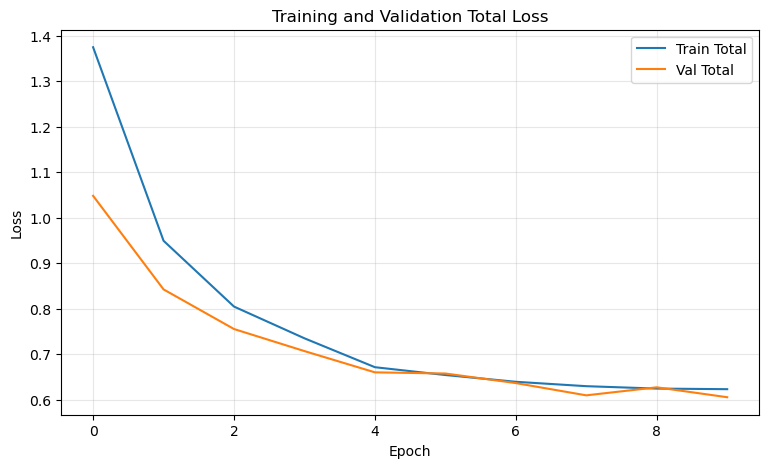

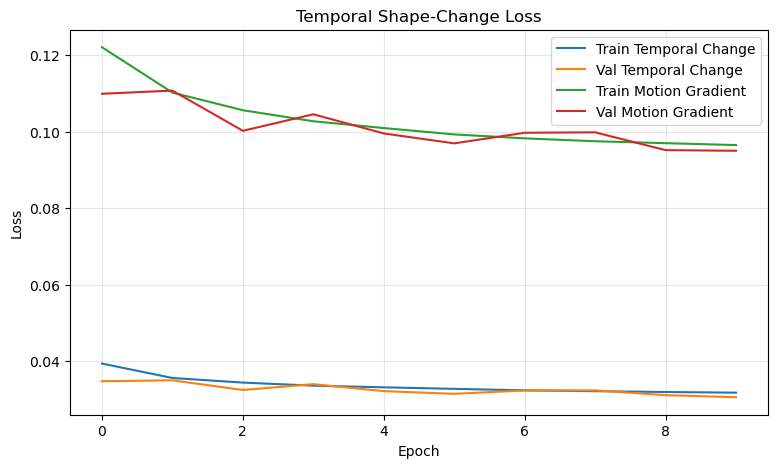


SAVING TWO-ROW PLOTS FOR VALIDATION SAMPLES
Validation samples available : 419
Validation samples to plot   : 419
Save directory               : /scratch.global/1subed042/diffusion_nowcast_final_temporal_shape_all_val/all_validation_two_row_plots


Saving validation plots: 100%|██████████| 419/419 [09:30<00:00,  1.36s/it]


Saved 419 validation figures.


In [14]:
def main():
    print("=" * 70)
    print("LOADING DATASET")
    print("=" * 70)

    dataset = MRMSResidualNowcastDataset(
        data_dir=DATA_DIR,
        input_steps=INPUT_STEPS,
        output_steps=OUTPUT_STEPS,
        rain_norm=RAIN_NORM,
        rain_threshold=RAIN_THRESHOLD
    )

    if len(dataset) == 0:
        raise ValueError("No valid .npz files found.")

    n_total = len(dataset)
    n_train = int(TRAIN_RATIO * n_total)
    n_val = int(VAL_RATIO * n_total)
    n_test = n_total - n_train - n_val

    train_set, val_set, test_set = random_split(
        dataset,
        [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(SEED)
    )

    print(f"Total : {n_total}")
    print(f"Train : {n_train}")
    print(f"Val   : {n_val}")
    print(f"Test  : {n_test}")

    train_loader = DataLoader(
        train_set,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=False
    )

    val_loader = DataLoader(
        val_set,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=False
    )

    test_loader = DataLoader(
        test_set,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=False
    )

    print("\n" + "=" * 70)
    print("BUILDING DIFFUSION MODEL")
    print("=" * 70)

    model = ResidualConditionalUNet(
        cond_ch=INPUT_STEPS,
        target_ch=OUTPUT_STEPS,
        cond_emb_ch=COND_EMB_CHANNELS,
        base_ch=BASE_CHANNELS,
        time_emb_dim=TIME_EMB_DIM
    ).to(DEVICE)

    total_params = sum(p.numel() for p in model.parameters())

    print(f"Device           : {DEVICE}")
    print(f"Total parameters : {total_params / 1e6:.2f} M")

    scheduler = DiffusionScheduler(
        timesteps=DIFFUSION_STEPS,
        beta_start=BETA_START,
        beta_end=BETA_END,
        device=DEVICE
    )

    optimizer = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(USE_AMP and DEVICE.startswith("cuda"))
    )

    best_val = np.inf

    history = {
        "train_total": [],
        "val_total": [],
        "train_change": [],
        "val_change": [],
        "train_motion_grad": [],
        "val_motion_grad": [],
        "train_dry": [],
        "val_dry": []
    }

    print("\n" + "=" * 70)
    print("TRAINING")
    print("=" * 70)

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")

        train_metrics = train_one_epoch(
            model=model,
            scheduler=scheduler,
            loader=train_loader,
            optimizer=optimizer,
            scaler=scaler,
            device=DEVICE
        )

        val_metrics = validate_one_epoch(
            model=model,
            scheduler=scheduler,
            loader=val_loader,
            device=DEVICE
        )

        lr_scheduler.step(val_metrics["total"])

        history["train_total"].append(train_metrics["total"])
        history["val_total"].append(val_metrics["total"])
        history["train_change"].append(train_metrics["change"])
        history["val_change"].append(val_metrics["change"])
        history["train_motion_grad"].append(train_metrics["motion_grad"])
        history["val_motion_grad"].append(val_metrics["motion_grad"])
        history["train_dry"].append(train_metrics["dry"])
        history["val_dry"].append(val_metrics["dry"])

        print(
            f"Train total: {train_metrics['total']:.6f} | "
            f"dry: {train_metrics['dry']:.6f} | "
            f"change: {train_metrics['change']:.6f} | "
            f"motion_grad: {train_metrics['motion_grad']:.6f}"
        )

        print(
            f"Val   total: {val_metrics['total']:.6f} | "
            f"dry: {val_metrics['dry']:.6f} | "
            f"change: {val_metrics['change']:.6f} | "
            f"motion_grad: {val_metrics['motion_grad']:.6f}"
        )

        if val_metrics["total"] < best_val:
            best_val = val_metrics["total"]

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "best_val": best_val,
                    "epoch": epoch + 1,
                    "settings": {
                        "RAIN_NORM": RAIN_NORM,
                        "RAIN_THRESHOLD": RAIN_THRESHOLD,
                        "POST_RAIN_THRESHOLD_MMHR": POST_RAIN_THRESHOLD_MMHR,
                        "RESIDUAL_CLAMP": RESIDUAL_CLAMP,
                        "LAMBDA_TEMPORAL_CHANGE": LAMBDA_TEMPORAL_CHANGE,
                        "LAMBDA_MOTION_GRAD": LAMBDA_MOTION_GRAD,
                        "LAMBDA_DIVERSITY": LAMBDA_DIVERSITY,
                    }
                },
                MODEL_PATH
            )

            print(f"Saved best model to: {MODEL_PATH}")

    print("\nLoading best model...")
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    print("\n" + "=" * 70)
    print("EVALUATING BEST MODEL")
    print("=" * 70)

    evaluate_loader(
        model=model,
        scheduler=scheduler,
        loader=val_loader,
        device=DEVICE,
        name="Validation"
    )

    evaluate_loader(
        model=model,
        scheduler=scheduler,
        loader=test_loader,
        device=DEVICE,
        name="Test"
    )

    # ========================================================
    # LOSS PLOTS
    # ========================================================
    plt.figure(figsize=(9, 5))
    plt.plot(history["train_total"], label="Train Total")
    plt.plot(history["val_total"], label="Val Total")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Total Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(os.path.join(SAVE_DIR, "training_total_loss.png"), dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(history["train_change"], label="Train Temporal Change")
    plt.plot(history["val_change"], label="Val Temporal Change")
    plt.plot(history["train_motion_grad"], label="Train Motion Gradient")
    plt.plot(history["val_motion_grad"], label="Val Motion Gradient")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Temporal Shape-Change Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(os.path.join(SAVE_DIR, "temporal_shape_loss.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # ========================================================
    # SAVE ALL VALIDATION TWO-ROW PLOTS
    # ========================================================
    save_all_validation_two_row_plots(
        model=model,
        scheduler=scheduler,
        dataset=dataset,
        val_set=val_set,
        device=DEVICE,
        save_dir=VAL_FIG_DIR,
        max_plots=MAX_VAL_PLOTS
    )


if __name__ == "__main__":
    main()

# Part B — Independent physics-guided inference and validation

This part loads the trained checkpoint, generates multiple diffusion realizations for each validation sample, applies physics-guided scoring based on advection diffusion equation and total mass flux, and saves the best realization plots.

## Part B: Initial Setup

In [15]:

import os
import glob
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

## Part B: User Settings

Define file paths and inference settings for the independent physics-guided validation script.

In [16]:
DATA_DIR = "/scratch.global/1subed042/mrms_3hr_cubes_128"

MODEL_PATH = (
    "/scratch.global/1subed042/diffusion_nowcast_final_temporal_shape_all_val/"
    "best_diffusion_nowcast_temporal_shape.pth"
)

SAVE_DIR = "/scratch.global/1subed042/physics_guided_20realization_validation_plots"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

INPUT_STEPS = 60
OUTPUT_STEPS = 30
TOTAL_STEPS = INPUT_STEPS + OUTPUT_STEPS

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

BATCH_SIZE = 1
NUM_WORKERS = 2

DIFFUSION_STEPS = 50
BETA_START = 1e-4
BETA_END = 0.02

BASE_CHANNELS = 64
TIME_EMB_DIM = 256
COND_EMB_CHANNELS = 32

RAIN_NORM = 20.0
RAIN_THRESHOLD = 0.2
RAIN_THRESHOLD_NORM = RAIN_THRESHOLD / RAIN_NORM

POST_RAIN_THRESHOLD_MMHR = 0.35
POST_RAIN_THRESHOLD_NORM = POST_RAIN_THRESHOLD_MMHR / RAIN_NORM

RESIDUAL_CLAMP = 0.90

N_REALIZATIONS = 20

ADVECTION_DIFFUSION_STEPS = 3
DIFFUSIVITY = 0.04
ADVECTION_BLEND = 0.25

VIS_STEPS = [0, 4, 9, 19, 29]

MAX_VAL_PLOTS = None   # None = all validation samples

colors_rain = ["gainsboro", "seagreen", "green", "yellow", "darkorange", "red"]
cmap_rate_rain = LinearSegmentedColormap.from_list("rain_cmap", colors_rain)
cmap_rate_rain.set_bad(color="white")

## Part B: Seed

Set random seeds for reproducibility across NumPy, Python, and PyTorch.

In [17]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

## Part B: Baseline Functions

Helper functions for normalized rainfall fields, motion estimates, and baseline generation.

In [18]:
def shift_image_np(img, dy, dx):
    h, w = img.shape
    out = np.zeros_like(img)

    iy = int(round(dy))
    ix = int(round(dx))

    y1_src = max(0, -iy)
    y2_src = min(h, h - iy)
    x1_src = max(0, -ix)
    x2_src = min(w, w - ix)

    y1_dst = max(0, iy)
    y2_dst = min(h, h + iy)
    x1_dst = max(0, ix)
    x2_dst = min(w, w + ix)

    if y2_src > y1_src and x2_src > x1_src:
        out[y1_dst:y2_dst, x1_dst:x2_dst] = img[y1_src:y2_src, x1_src:x2_src]

    return out


def estimate_motion_and_make_baseline_sequence(x_abs, output_steps=30, threshold=0.2):
    f1 = x_abs[-10]
    f2 = x_abs[-1]

    yy, xx = np.indices(f1.shape)

    m1 = f1 > threshold
    m2 = f2 > threshold

    if m1.sum() < 10 or m2.sum() < 10:
        dy, dx = 0.0, 0.0
    else:
        cy1 = (yy[m1] * f1[m1]).sum() / (f1[m1].sum() + 1e-6)
        cx1 = (xx[m1] * f1[m1]).sum() / (f1[m1].sum() + 1e-6)

        cy2 = (yy[m2] * f2[m2]).sum() / (f2[m2].sum() + 1e-6)
        cx2 = (xx[m2] * f2[m2]).sum() / (f2[m2].sum() + 1e-6)

        dy = float(np.clip((cy2 - cy1) / 9.0, -2.0, 2.0))
        dx = float(np.clip((cx2 - cx1) / 9.0, -2.0, 2.0))

    base = np.mean(x_abs[-5:], axis=0)

    seq = []
    for k in range(output_steps):
        seq.append(shift_image_np(base, dy * (k + 1), dx * (k + 1)))

    seq = np.stack(seq, axis=0).astype(np.float32)
    return seq, dy, dx

## Part B: Dataset

Dataset class for loading MRMS 3-hour rainfall cubes and splitting them into input and target sequences.

In [19]:
class MRMSResidualNowcastDataset(Dataset):
    def __init__(self, data_dir):
        self.files = sorted(glob.glob(os.path.join(data_dir, "*.npz")))

        valid = []
        print("Checking valid files...")
        for f in tqdm(self.files):
            try:
                d = np.load(f)
                p = d["precip"]
                if p.shape[0] >= TOTAL_STEPS:
                    valid.append(f)
            except Exception:
                pass

        self.files = valid
        print(f"Total valid files: {len(self.files)}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        d = np.load(path)

        precip = d["precip"].astype(np.float32)
        precip = np.nan_to_num(precip, nan=0.0, posinf=0.0, neginf=0.0)
        precip = np.clip(precip, 0.0, None)

        x_abs = precip[:INPUT_STEPS]
        y_abs = precip[INPUT_STEPS:INPUT_STEPS + OUTPUT_STEPS]

        x_abs[x_abs < RAIN_THRESHOLD] = 0.0
        y_abs[y_abs < RAIN_THRESHOLD] = 0.0

        baseline, dy, dx = estimate_motion_and_make_baseline_sequence(
            x_abs,
            output_steps=OUTPUT_STEPS,
            threshold=RAIN_THRESHOLD
        )

        residual = y_abs - baseline

        return {
            "cond": torch.tensor(x_abs / RAIN_NORM, dtype=torch.float32),
            "target_residual": torch.tensor(residual / RAIN_NORM, dtype=torch.float32),
            "baseline": torch.tensor(baseline / RAIN_NORM, dtype=torch.float32),
            "target_abs": torch.tensor(y_abs / RAIN_NORM, dtype=torch.float32),
            "motion": torch.tensor([dy, dx], dtype=torch.float32),
            "file_path": path,
            "dataset_idx": idx
        }

## Part B: Model

Neural network architecture used inside the conditional DDPM. The model receives noisy future rainfall, diffusion time, and conditioning frames.

In [20]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        factor = math.log(10000) / max(half_dim - 1, 1)

        emb = torch.exp(torch.arange(half_dim, device=device) * -factor)
        emb = time[:, None].float() * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb


def conv3x3(in_ch, out_ch):
    return nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, padding_mode="reflect")


class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim=None):
        super().__init__()

        self.time_mlp = None
        if time_emb_dim is not None:
            self.time_mlp = nn.Sequential(
                nn.SiLU(),
                nn.Linear(time_emb_dim, out_ch)
            )

        self.conv1 = conv3x3(in_ch, out_ch)
        self.norm1 = nn.GroupNorm(8, out_ch)

        self.conv2 = conv3x3(out_ch, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)

        self.residual = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb=None):
        h = F.silu(self.norm1(self.conv1(x)))

        if self.time_mlp is not None and t_emb is not None:
            h = h + self.time_mlp(t_emb)[:, :, None, None]

        h = F.silu(self.norm2(self.conv2(h)))
        return h + self.residual(x)


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()

        self.block1 = ResidualBlock(in_ch, out_ch, time_emb_dim)
        self.block2 = ResidualBlock(out_ch, out_ch, time_emb_dim)

        self.down = nn.Conv2d(
            out_ch,
            out_ch,
            kernel_size=4,
            stride=2,
            padding=1,
            padding_mode="reflect"
        )

    def forward(self, x, t_emb):
        x = self.block1(x, t_emb)
        x = self.block2(x, t_emb)
        skip = x
        x = self.down(x)
        return x, skip


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, time_emb_dim):
        super().__init__()

        self.conv_in = conv3x3(in_ch + skip_ch, out_ch)
        self.block1 = ResidualBlock(out_ch, out_ch, time_emb_dim)
        self.block2 = ResidualBlock(out_ch, out_ch, time_emb_dim)

    def forward(self, x, skip, t_emb):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.conv_in(x)
        x = self.block1(x, t_emb)
        x = self.block2(x, t_emb)
        return x


class ConditionEncoder(nn.Module):
    def __init__(self, in_ch=60, out_ch=32):
        super().__init__()

        self.net = nn.Sequential(
            conv3x3(in_ch, 64),
            nn.GELU(),
            conv3x3(64, 64),
            nn.GELU(),
            conv3x3(64, out_ch),
            nn.GELU()
        )

    def forward(self, cond):
        return self.net(cond)


class ResidualConditionalUNet(nn.Module):
    def __init__(self, cond_ch=60, target_ch=30,
                 cond_emb_ch=32, base_ch=64, time_emb_dim=256):
        super().__init__()

        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        self.cond_encoder = ConditionEncoder(cond_ch, cond_emb_ch)

        self.init_conv = conv3x3(target_ch + cond_emb_ch, base_ch)

        self.down1 = DownBlock(base_ch + cond_emb_ch, base_ch, time_emb_dim)
        self.down2 = DownBlock(base_ch + cond_emb_ch, base_ch * 2, time_emb_dim)
        self.down3 = DownBlock(base_ch * 2 + cond_emb_ch, base_ch * 4, time_emb_dim)

        self.mid1 = ResidualBlock(base_ch * 4 + cond_emb_ch, base_ch * 4, time_emb_dim)
        self.mid2 = ResidualBlock(base_ch * 4, base_ch * 4, time_emb_dim)

        self.up1 = UpBlock(base_ch * 4, base_ch * 4, base_ch * 2, time_emb_dim)
        self.up2 = UpBlock(base_ch * 2, base_ch * 2, base_ch, time_emb_dim)
        self.up3 = UpBlock(base_ch, base_ch, base_ch, time_emb_dim)

        self.final_block = ResidualBlock(base_ch, base_ch, time_emb_dim)

        self.final_noise = nn.Conv2d(base_ch, target_ch, kernel_size=1)
        self.final_x0 = nn.Conv2d(base_ch, target_ch, kernel_size=1)

    def forward(self, x_noisy, cond, t):
        t_emb = self.time_embed(t)

        cond0 = self.cond_encoder(cond)
        cond1 = F.avg_pool2d(cond0, 2)
        cond2 = F.avg_pool2d(cond1, 2)
        cond3 = F.avg_pool2d(cond2, 2)

        x = torch.cat([x_noisy, cond0], dim=1)
        x = self.init_conv(x)

        x = torch.cat([x, cond0], dim=1)
        x, s1 = self.down1(x, t_emb)

        x = torch.cat([x, cond1], dim=1)
        x, s2 = self.down2(x, t_emb)

        x = torch.cat([x, cond2], dim=1)
        x, s3 = self.down3(x, t_emb)

        x = torch.cat([x, cond3], dim=1)
        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        x = self.up1(x, s3, t_emb)
        x = self.up2(x, s2, t_emb)
        x = self.up3(x, s1, t_emb)

        x = self.final_block(x, t_emb)

        return self.final_noise(x), self.final_x0(x)

## Part B: Diffusion Scheduler

Defines the DDPM noise schedule, forward noising coefficients, and reverse-process constants.

In [21]:
class DiffusionScheduler:
    def __init__(self, timesteps=50, beta_start=1e-4, beta_end=0.02, device="cpu"):
        self.timesteps = timesteps
        self.device = device

        self.betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_cumprod = torch.cumprod(self.alphas, dim=0)

## Part B: Physics Guidance

Physics scoring and correction utilities used to select the most plausible realization from multiple DDPM samples.

In [22]:
def remove_tiny_isolated_rain_torch(x, threshold_norm=POST_RAIN_THRESHOLD_NORM):
    rain = (x > threshold_norm).float()
    b, t, h, w = rain.shape

    rain_2d = rain.reshape(b * t, 1, h, w)

    neighbor_count = F.avg_pool2d(
        rain_2d,
        kernel_size=5,
        stride=1,
        padding=2
    ) * 25.0

    neighbor_count = neighbor_count.reshape(b, t, h, w)
    keep = neighbor_count >= 4.0

    return torch.where(keep, x, torch.zeros_like(x))


def make_time_dependent_support_from_baseline(baseline):
    support = baseline / (baseline.amax(dim=[2, 3], keepdim=True) + 1e-6)
    support = torch.clamp(support, 0.0, 1.0)

    support = F.avg_pool2d(
        support.reshape(-1, 1, support.shape[-2], support.shape[-1]),
        kernel_size=5,
        stride=1,
        padding=2
    ).reshape_as(support)

    return support ** 0.75


def estimate_velocity_from_cond_torch(cond):
    b, tin, h, w = cond.shape
    device = cond.device

    f1 = cond[:, -10]
    f2 = cond[:, -1]

    yy, xx = torch.meshgrid(
        torch.arange(h, device=device),
        torch.arange(w, device=device),
        indexing="ij"
    )

    yy = yy.float()[None]
    xx = xx.float()[None]

    m1 = (f1 > RAIN_THRESHOLD_NORM).float()
    m2 = (f2 > RAIN_THRESHOLD_NORM).float()

    mass1 = torch.sum(f1 * m1, dim=[1, 2]) + 1e-6
    mass2 = torch.sum(f2 * m2, dim=[1, 2]) + 1e-6

    cy1 = torch.sum(yy * f1 * m1, dim=[1, 2]) / mass1
    cx1 = torch.sum(xx * f1 * m1, dim=[1, 2]) / mass1

    cy2 = torch.sum(yy * f2 * m2, dim=[1, 2]) / mass2
    cx2 = torch.sum(xx * f2 * m2, dim=[1, 2]) / mass2

    dy = torch.clamp((cy2 - cy1) / 9.0, -2.0, 2.0)
    dx = torch.clamp((cx2 - cx1) / 9.0, -2.0, 2.0)

    weak = ((m1.sum(dim=[1, 2]) < 10) | (m2.sum(dim=[1, 2]) < 10))
    dy = torch.where(weak, torch.zeros_like(dy), dy)
    dx = torch.where(weak, torch.zeros_like(dx), dx)

    return dy, dx


def shift_frame_torch(x, dy, dx):
    b, c, h, w = x.shape
    device = x.device

    yy, xx = torch.meshgrid(
        torch.linspace(-1, 1, h, device=device),
        torch.linspace(-1, 1, w, device=device),
        indexing="ij"
    )

    grid = torch.stack([xx, yy], dim=-1)[None].repeat(b, 1, 1, 1)

    dx_norm = 2.0 * dx / max(w - 1, 1)
    dy_norm = 2.0 * dy / max(h - 1, 1)

    grid[..., 0] = grid[..., 0] - dx_norm[:, None, None]
    grid[..., 1] = grid[..., 1] - dy_norm[:, None, None]

    return F.grid_sample(
        x,
        grid,
        mode="bilinear",
        padding_mode="zeros",
        align_corners=True
    )


def laplacian_2d(x):
    b, t, h, w = x.shape
    x2 = x.reshape(b * t, 1, h, w)

    kernel = torch.tensor(
        [[0.0, 1.0, 0.0],
         [1.0, -4.0, 1.0],
         [0.0, 1.0, 0.0]],
        device=x.device,
        dtype=x.dtype
    ).view(1, 1, 3, 3)

    lap = F.conv2d(x2, kernel, padding=1)
    return lap.reshape(b, t, h, w)


def apply_advection_diffusion_guidance(pred_abs, cond):
    pred = pred_abs.clone()
    dy, dx = estimate_velocity_from_cond_torch(cond)

    for _ in range(ADVECTION_DIFFUSION_STEPS):
        advected_frames = []

        for k in range(pred.shape[1]):
            lead = float(k + 1)

            shifted = shift_frame_torch(
                pred[:, k:k + 1],
                dy * lead,
                dx * lead
            )

            advected_frames.append(shifted[:, 0])

        advected = torch.stack(advected_frames, dim=1)

        diffused = pred + DIFFUSIVITY * laplacian_2d(pred)
        diffused = torch.clamp(diffused, min=0.0)

        pred = (1.0 - ADVECTION_BLEND) * pred + ADVECTION_BLEND * advected
        pred = 0.85 * pred + 0.15 * diffused
        pred = torch.clamp(pred, min=0.0)

    return pred


@torch.no_grad()
def physics_score_candidate(pred_abs, cond, baseline):
    last_obs = cond[:, -1:]
    first_pred = pred_abs[:, :1]

    continuity = F.l1_loss(first_pred, last_obs)

    dt = pred_abs[:, 1:] - pred_abs[:, :-1]
    temporal_smooth = torch.mean(torch.abs(dt))

    dx = pred_abs[:, :, :, 1:] - pred_abs[:, :, :, :-1]
    dy = pred_abs[:, :, 1:, :] - pred_abs[:, :, :-1, :]
    spatial_smooth = torch.mean(torch.abs(dx)) + torch.mean(torch.abs(dy))

    mass = pred_abs.sum(dim=[2, 3])
    mass_change = torch.mean(torch.abs(mass[:, 1:] - mass[:, :-1]))

    baseline_mass = baseline.sum(dim=[2, 3]) + 1e-6
    pred_mass = pred_abs.sum(dim=[2, 3])
    mass_ratio_penalty = torch.mean(torch.abs(pred_mass / baseline_mass - 1.0))

    dry_mask = last_obs <= RAIN_THRESHOLD_NORM
    dry_mask = dry_mask.repeat(1, OUTPUT_STEPS, 1, 1)

    false_rain = torch.clamp(pred_abs - POST_RAIN_THRESHOLD_NORM, min=0.0)
    dry_penalty = torch.mean(false_rain * dry_mask.float())

    support = make_time_dependent_support_from_baseline(baseline)
    outside_support = torch.mean(pred_abs * (1.0 - support))

    score = (
        1.4 * continuity
        + 0.45 * temporal_smooth
        + 0.04 * spatial_smooth
        + 0.65 * mass_change
        + 0.50 * mass_ratio_penalty
        + 2.2 * dry_penalty
        + 1.2 * outside_support
    )

    return score.item()

## Part B: Diffusion Sampling

Independent sampling functions used during physics-guided validation and realization selection.

In [23]:
@torch.no_grad()
def sample_one_future_absolute(model, scheduler, cond, baseline):
    model.eval()

    b, _, h, w = cond.shape

    x = torch.randn(
        (b, OUTPUT_STEPS, h, w),
        device=cond.device
    )

    for i in reversed(range(scheduler.timesteps)):
        t = torch.full(
            (b,),
            i,
            device=cond.device,
            dtype=torch.long
        )

        pred_noise, pred_x0_direct = model(x, cond, t)

        alpha = scheduler.alphas[i]
        alpha_bar = scheduler.alpha_cumprod[i]
        beta = scheduler.betas[i]

        mean = (1.0 / torch.sqrt(alpha)) * (
            x - ((1.0 - alpha) / torch.sqrt(1.0 - alpha_bar)) * pred_noise
        )

        if i > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(beta) * noise
        else:
            x = mean

        x = 0.92 * x + 0.08 * pred_x0_direct
        x = torch.clamp(x, -RESIDUAL_CLAMP, RESIDUAL_CLAMP)

    pred_abs = x + baseline
    pred_abs = torch.clamp(pred_abs, min=0.0)

    support = make_time_dependent_support_from_baseline(baseline)
    pred_abs = pred_abs * (0.15 + 0.85 * support)

    max_allowed = 1.80 * baseline + (2.00 / RAIN_NORM)
    pred_abs = torch.minimum(pred_abs, max_allowed)

    pred_abs = apply_advection_diffusion_guidance(pred_abs, cond)

    pred_abs = torch.where(
        pred_abs < POST_RAIN_THRESHOLD_NORM,
        torch.zeros_like(pred_abs),
        pred_abs
    )

    pred_abs = remove_tiny_isolated_rain_torch(pred_abs)

    return pred_abs


@torch.no_grad()
def sample_best_physics_guided_realization(model, scheduler, cond, baseline):
    best_pred = None
    best_score = float("inf")
    all_scores = []

    for r in range(N_REALIZATIONS):
        pred_abs = sample_one_future_absolute(
            model=model,
            scheduler=scheduler,
            cond=cond,
            baseline=baseline
        )

        score = physics_score_candidate(
            pred_abs=pred_abs,
            cond=cond,
            baseline=baseline
        )

        all_scores.append(score)

        if score < best_score:
            best_score = score
            best_pred = pred_abs.clone()
            best_id = r

    return best_pred, best_score, best_id, all_scores

## Part B: Plotting With Mae, Wasserstein Distance, And Correlation

Enhanced visualization that prints MAE, Wasserstein distance, and correlation below each predicted frame.

In [24]:
from scipy.stats import wasserstein_distance


def compute_patch_metrics(true_img, pred_img):
    true_flat = true_img.reshape(-1)
    pred_flat = pred_img.reshape(-1)

    mae = np.mean(np.abs(pred_flat - true_flat))
    wd = wasserstein_distance(true_flat, pred_flat)

    if np.std(true_flat) < 1e-8 or np.std(pred_flat) < 1e-8:
        corr = np.nan
    else:
        corr = np.corrcoef(true_flat, pred_flat)[0, 1]

    return mae, wd, corr


@torch.no_grad()
def plot_two_row_sample(model, scheduler, sample, local_i):
    model.eval()

    cond = sample["cond"].unsqueeze(0).to(DEVICE)
    baseline = sample["baseline"].unsqueeze(0).to(DEVICE)

    y_true = sample["target_abs"].cpu().numpy() * RAIN_NORM

    pred_abs, best_score, best_id, scores = sample_best_physics_guided_realization(
        model=model,
        scheduler=scheduler,
        cond=cond,
        baseline=baseline
    )

    y_pred = pred_abs.squeeze(0).cpu().numpy() * RAIN_NORM
    y_pred = np.clip(y_pred, 0.0, None)
    y_pred[y_pred < POST_RAIN_THRESHOLD_MMHR] = 0.0

    plt.rcParams.update({"font.family": "serif"})

    n = len(VIS_STEPS)
    vmin, vmax = 0, 10

    # Taller figure + extra bottom margin for metrics
    fig, axes = plt.subplots(2, n, figsize=(4.5 * n, 8.4))
    plt.subplots_adjust(
        wspace=0.04,
        hspace=0.32,
        right=0.92,
        bottom=0.12
    )

    for j, t in enumerate(VIS_STEPS):
        lead_min = (t + 1) * 2

        axes[0, j].imshow(
            y_true[t],
            cmap=cmap_rate_rain,
            vmin=vmin,
            vmax=vmax,
            origin="lower"
        )
        axes[0, j].set_title(
            f"Truth\n+t{t + 1} ({lead_min} min)",
            fontsize=16,
            fontweight="bold"
        )
        axes[0, j].axis("off")

        axes[1, j].imshow(
            y_pred[t],
            cmap=cmap_rate_rain,
            vmin=vmin,
            vmax=vmax,
            origin="lower"
        )
        axes[1, j].set_title(
            f"Prediction\n+t{t + 1} ({lead_min} min)",
            fontsize=16,
            fontweight="bold"
        )
        axes[1, j].axis("off")

        # Metrics below predicted image
        mae, wd, corr = compute_patch_metrics(y_true[t], y_pred[t])

        metric_text = (
            f"MAE = {mae:.3f}\n"
            f"WD = {wd:.3f}\n"
            f"Corr = {corr:.3f}"
        )

        axes[1, j].text(
            0.5,
            -0.13,
            metric_text,
            transform=axes[1, j].transAxes,
            ha="center",
            va="top",
            fontsize=13,
            fontweight="bold"
        )

    sm = ScalarMappable(
        norm=Normalize(vmin=vmin, vmax=vmax),
        cmap=cmap_rate_rain
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        fraction=0.025,
        pad=0.01,
        shrink=0.9
    )

    cbar.set_label(
        r"Rain Rate (mm hr$^{-1}$)",
        fontsize=18,
        fontweight="bold",
        rotation=90,
        labelpad=18
    )
    cbar.ax.tick_params(labelsize=14, width=1.2)

    save_name = (
        f"val_{local_i:05d}_datasetidx_{sample['dataset_idx']:07d}_"
        f"best_realization_{best_id + 1:02d}_of_{N_REALIZATIONS}.png"
    )

    save_path = os.path.join(SAVE_DIR, save_name)

    plt.savefig(save_path, dpi=250, bbox_inches="tight")
    plt.close(fig)

    return save_path, best_score, best_id, scores

## Part B: Main

Main execution cell. Run this after reviewing and updating all paths/settings.

In [ ]:
def main():
    print("=" * 70)
    print("LOADING DATASET")
    print("=" * 70)

    dataset = MRMSResidualNowcastDataset(DATA_DIR)

    n_total = len(dataset)
    n_train = int(TRAIN_RATIO * n_total)
    n_val = int(VAL_RATIO * n_total)
    n_test = n_total - n_train - n_val

    train_set, val_set, test_set = random_split(
        dataset,
        [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(SEED)
    )

    print(f"Total : {n_total}")
    print(f"Train : {n_train}")
    print(f"Val   : {n_val}")
    print(f"Test  : {n_test}")

    print("\n" + "=" * 70)
    print("BUILDING MODEL")
    print("=" * 70)

    model = ResidualConditionalUNet(
        cond_ch=INPUT_STEPS,
        target_ch=OUTPUT_STEPS,
        cond_emb_ch=COND_EMB_CHANNELS,
        base_ch=BASE_CHANNELS,
        time_emb_dim=TIME_EMB_DIM
    ).to(DEVICE)

    scheduler = DiffusionScheduler(
        timesteps=DIFFUSION_STEPS,
        beta_start=BETA_START,
        beta_end=BETA_END,
        device=DEVICE
    )

    print(f"Device: {DEVICE}")
    print(f"Loading checkpoint: {MODEL_PATH}")

    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

    if "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    model.eval()

    print("Model loaded successfully.")

    n_plot = len(val_set) if MAX_VAL_PLOTS is None else min(MAX_VAL_PLOTS, len(val_set))

    print("\n" + "=" * 70)
    print("GENERATING PHYSICS-GUIDED VALIDATION PLOTS")
    print("=" * 70)
    print(f"Validation samples to plot : {n_plot}")
    print(f"Realizations per sample    : {N_REALIZATIONS}")
    print(f"Save directory             : {SAVE_DIR}")

    summary_rows = []

    for local_i in tqdm(range(n_plot), desc="Validation plots"):
        actual_idx = val_set.indices[local_i]
        sample = dataset[actual_idx]

        save_path, best_score, best_id, scores = plot_two_row_sample(
            model=model,
            scheduler=scheduler,
            sample=sample,
            local_i=local_i
        )

        summary_rows.append([
            local_i,
            actual_idx,
            best_id + 1,
            best_score,
            np.min(scores),
            np.mean(scores),
            np.max(scores),
            save_path
        ])

    summary_path = os.path.join(SAVE_DIR, "physics_guided_realization_summary.csv")

    with open(summary_path, "w") as f:
        f.write("val_local_idx,dataset_idx,best_realization,best_score,min_score,mean_score,max_score,figure_path\n")
        for row in summary_rows:
            f.write(",".join(map(str, row)) + "\n")

    print("\nDone.")
    print(f"Saved plots to: {SAVE_DIR}")
    print(f"Saved summary CSV to: {summary_path}")


if __name__ == "__main__":
    main()

LOADING DATASET
Checking valid files...


100%|██████████| 2794/2794 [00:29<00:00, 93.95it/s] 
/tmp/ipykernel_585996/2399732239.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH

Total valid files: 2794
Total : 2794
Train : 1955
Val   : 419
Test  : 420

BUILDING MODEL
Device: cuda
Loading checkpoint: /scratch.global/1subed042/diffusion_nowcast_final_temporal_shape_all_val/best_diffusion_nowcast_temporal_shape.pth
Model loaded successfully.

GENERATING PHYSICS-GUIDED VALIDATION PLOTS
Validation samples to plot : 419
Realizations per sample    : 20
Save directory             : /scratch.global/1subed042/physics_guided_20realization_validation_plots


Validation plots:  82%|████████▏ | 345/419 [49:42<10:40,  8.66s/it] 